# BRP Exploration and Field Sample

This notebook explores the Dutch BRP field data and creates a clean sample of labeled crop fields for the satellite notebook.

## 1. Load and Inspect BRP

Load the BRP GeoPackage, check the columns, and confirm the coordinate system.

In [28]:
from pathlib import Path

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import box

BRP_PATH = Path("../data/brp_2025.gpkg")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 40)

brp_gdf = gpd.read_file(BRP_PATH)

print(f"Total parcels: {len(brp_gdf):,}")
print(f"CRS: {brp_gdf.crs}")
print("Columns:")
for column in brp_gdf.columns:
    print(f"- {column}")

display(brp_gdf.head())

/Users/rickpeters/Desktop/YieldPredictionModel/.venv/lib/python3.12/site-packages/pyogrio/raw.py:200: UserWarning: Measured (M) geometry types are not supported. Original type 'Measured 3D Polygon' is converted to 'Polygon Z'
  return ogr_read(


Total parcels: 2,331,084
CRS: EPSG:28992
Columns:
- category
- gewas
- gewascode
- jaar
- status
- geometry


,category,gewas,gewascode,jaar,status,geometry
0,Landschapselement,Sloot,343,2025,Definitief,"POLYGON ((65544.876 383512.682, 65557.222 3835..."
1,Bouwland,"Overige bloemen, overige bloemkwekerijgewassen",991,2025,Definitief,"POLYGON ((68230.247 382132.963, 68297.306 3821..."
2,Grasland,"Grasland, blijvend",265,2025,Definitief,"POLYGON ((112088.897 458665.931, 112085.119 45..."
3,Grasland,"Grasland, blijvend",265,2025,Definitief,"POLYGON ((113219.88 456644.96, 113220.052 4566..."
4,Grasland,"Grasland, blijvend",265,2025,Definitief,"POLYGON ((113236.78 456777.5, 113237.28 456777..."


## 2. Explore Crops and Field Sizes

Check the crop label column, summarize common crops, and look at field sizes.


gewas:
['Sloot', 'Overige bloemen, overige bloemkwekerijgewassen', 'Grasland, blijvend', 'Grasland, blijvend', 'Grasland, blijvend', 'Grasland, blijvend', 'Uien, gele zaai-', 'Broccoli, productie', 'Broccoli, productie', 'Mais, snij-']

gewascode:
[343, 991, 265, 265, 265, 265, 6660, 2719, 2719, 259]
Unique crop categories: 370
Top 10 crops cover 86.96% of all parcels.


,crop,parcel_count,percentage
0,Sloot,815501,34.98
1,"Grasland, blijvend",629359,27.00
2,"Grasland, tijdelijk",139766,6.00
3,"Mais, snij-",95192,4.08
4,Houtwal en houtsingel,82124,3.52
5,"Groene braak, spontane opkomst",77223,3.31
6,Agrarisch natuurmengsel,68637,2.94
7,"Grasland, natuurlijk. Met landbouwactiviteiten.",67699,2.90
8,Natuurterreinen (incl. heide),30624,1.31
9,"Tarwe, winter-",21096,0.90


,area_ha
min,0.000001
max,2127.357804
mean,0.820156
50%,0.055739
25%,0.016823
75%,0.616905
std,3.205996


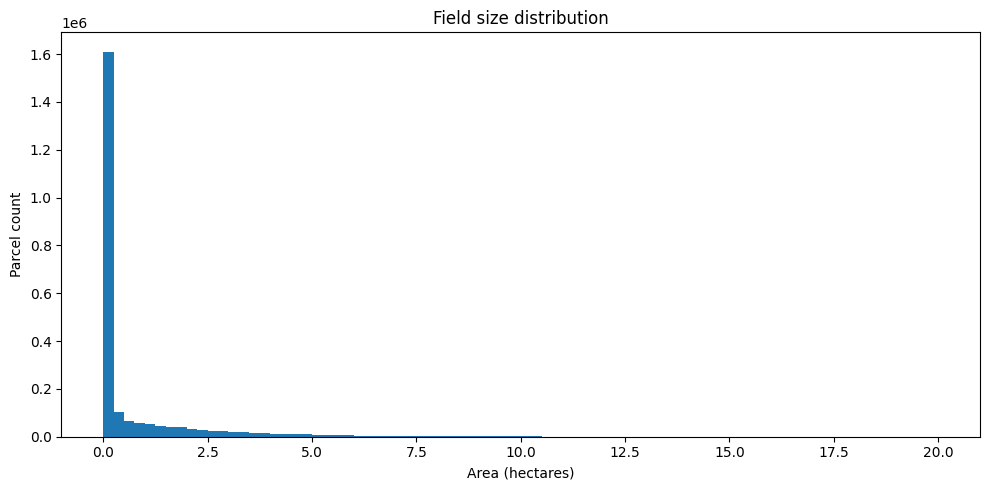

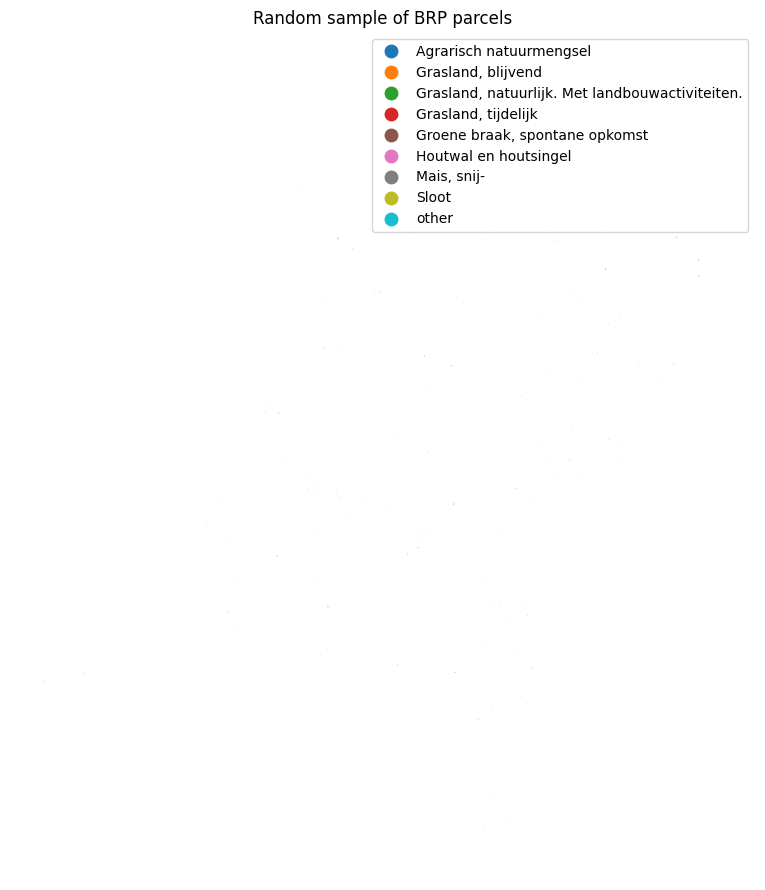

In [29]:
CROP_COLUMN = "gewas"

for column in brp_gdf.columns:
    if "gewas" in column.lower():
        print()
        print(f"{column}:")
        print(brp_gdf[column].dropna().head(10).to_list())

crop_counts = brp_gdf[CROP_COLUMN].fillna("Unknown").value_counts()
crop_table = crop_counts.head(30).reset_index()
crop_table.columns = ["crop", "parcel_count"]
crop_table["percentage"] = (crop_table["parcel_count"] / len(brp_gdf) * 100).round(2)

top_10_share = crop_counts.head(10).sum() / len(brp_gdf) * 100
print(f"Unique crop categories: {brp_gdf[CROP_COLUMN].nunique():,}")
print(f"Top 10 crops cover {top_10_share:.2f}% of all parcels.")
display(crop_table)

brp_gdf["area_ha"] = brp_gdf.geometry.area / 10_000
area_summary = brp_gdf["area_ha"].describe()[["min", "max", "mean", "50%", "25%", "75%", "std"]]
display(area_summary.to_frame("area_ha"))

fig, ax = plt.subplots(figsize=(10, 5))
brp_gdf["area_ha"].plot.hist(bins=80, range=(0, 20), ax=ax)
ax.set_title("Field size distribution")
ax.set_xlabel("Area (hectares)")
ax.set_ylabel("Parcel count")
plt.tight_layout()
plt.show()

top_8_crops = crop_counts.head(8).index.to_list()
map_sample = brp_gdf.sample(n=min(1_000, len(brp_gdf)), random_state=42).copy()
map_sample["crop_group"] = map_sample[CROP_COLUMN].where(map_sample[CROP_COLUMN].isin(top_8_crops), "other")

fig, ax = plt.subplots(figsize=(9, 9))
map_sample.plot(column="crop_group", categorical=True, legend=True, linewidth=0.1, ax=ax)
ax.set_title("Random sample of BRP parcels")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 3. Select the Study Region and Crop Parcels

Focus on a Noord-Brabant region and keep real crop fields: arable land and grassland.

Parcels in study region: 69,871


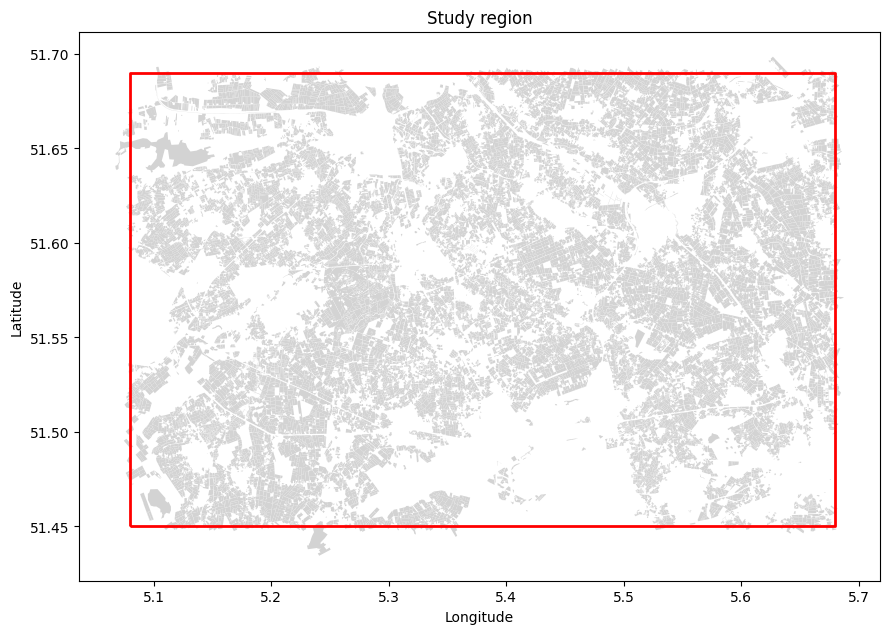

,category,parcel_count
0,Landschapselement,28749
1,Grasland,23026
2,Bouwland,16847
3,Natuurterrein,1041
4,Overige,193
5,Braakland,15


Crop parcels after category filter: 39,873


,crop,parcel_count
0,"Grasland, blijvend",12318
1,"Mais, snij-",6658
2,"Grasland, tijdelijk",6068
3,"Grasland, natuurlijk. Met landbouwactiviteiten.",2665
4,"Groene braak, spontane opkomst",2606
5,Agrarisch natuurmengsel,1608
6,"Aardappelen, consumptie",1266
7,"Laanbomen/parkbomen, opzetters, open grond",722
8,"Bieten, suiker-",384
9,"Grasland, natuurlijk. Hoofdfunctie natuur.",367


In [30]:
min_lon, min_lat = 5.08, 51.45
max_lon, max_lat = 5.68, 51.69

region_box = box(min_lon, min_lat, max_lon, max_lat)
region_box_gdf = gpd.GeoDataFrame(geometry=[region_box], crs="EPSG:4326")

brp_wgs84 = brp_gdf.to_crs("EPSG:4326")
brp_region = brp_wgs84[brp_wgs84.intersects(region_box)].copy()

print(f"Parcels in study region: {len(brp_region):,}")

fig, ax = plt.subplots(figsize=(9, 7))
brp_region.plot(ax=ax, color="lightgray", edgecolor="none")
region_box_gdf.boundary.plot(ax=ax, color="red", linewidth=2)
ax.set_title("Study region")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

category_counts = brp_region["category"].fillna("Unknown").value_counts().reset_index()
category_counts.columns = ["category", "parcel_count"]
display(category_counts)

brp_cropland = brp_region[brp_region["category"].isin(["Bouwland", "Grasland"])].copy()
print(f"Crop parcels after category filter: {len(brp_cropland):,}")

top_20_crops = brp_cropland[CROP_COLUMN].value_counts().head(20).reset_index()
top_20_crops.columns = ["crop", "parcel_count"]
display(top_20_crops)

## 4. Create and Save the Training Field Sample

Remove tiny fields, group detailed BRP crop names into seven broader classes, and save the final field sample.

In [31]:
brp_cropland["area_ha"] = brp_gdf.loc[brp_cropland.index, "area_ha"]
brp_filtered = brp_cropland[brp_cropland["area_ha"] >= 0.5].copy()

print(f"Fields after 0.5 ha filter: {len(brp_filtered):,}")
display(brp_filtered["area_ha"].agg(["min", "max", "mean", "median"]).to_frame("area_ha"))

def crop_class(crop_name):
    crop_name = "" if pd.isna(crop_name) else str(crop_name)
    if crop_name.startswith("Grasland"):
        return "Grass"
    if crop_name.startswith("Mais"):
        return "Maize"
    if crop_name.startswith("Aardappelen"):
        return "Potato"
    if crop_name.startswith("Tarwe"):
        return "Wheat"
    if crop_name.startswith("Gerst"):
        return "Barley"
    if crop_name.startswith("Bieten, suiker-"):
        return "Sugar beet"
    if crop_name.startswith("Uien"):
        return "Onion"
    return "Other"

brp_filtered["crop_class"] = brp_filtered[CROP_COLUMN].apply(crop_class)

class_counts = brp_filtered["crop_class"].value_counts().reset_index()
class_counts.columns = ["crop_class", "parcel_count"]
class_counts["percentage"] = (class_counts["parcel_count"] / len(brp_filtered) * 100).round(2)
display(class_counts)

training_fields = brp_filtered[brp_filtered["crop_class"] != "Other"].copy()

sampled_groups = []
for crop_name, group in training_fields.groupby("crop_class"):
    sample_size = min(800, len(group))
    sampled_groups.append(group.sample(n=sample_size, random_state=42))

sampled_fields = pd.concat(sampled_groups).sort_index()

sample_counts = sampled_fields["crop_class"].value_counts().reset_index()
sample_counts.columns = ["crop_class", "field_count"]
display(sample_counts)
print(f"Total sampled fields: {len(sampled_fields):,}")

sample_output_path = Path("../data/sampled_fields.gpkg")
sampled_fields[[CROP_COLUMN, "crop_class", "area_ha", "geometry"]].to_crs("EPSG:4326").to_file(
    sample_output_path,
    layer="sampled_fields",
    driver="GPKG",
)

print(f"Saved {len(sampled_fields):,} fields to {sample_output_path}")

Fields after 0.5 ha filter: 19,880


,area_ha
min,0.500017
max,35.004724
mean,2.247107
median,1.618870


,crop_class,parcel_count,percentage
0,Grass,10318,51.90
1,Maize,4803,24.16
2,Other,3009,15.14
3,Potato,1047,5.27
4,Sugar beet,297,1.49
5,Onion,164,0.82
6,Wheat,131,0.66
7,Barley,111,0.56


,crop_class,field_count
0,Grass,800
1,Potato,800
2,Maize,800
3,Sugar beet,297
4,Onion,164
5,Wheat,131
6,Barley,111


Total sampled fields: 3,103
Saved 3,103 fields to ../data/sampled_fields.gpkg
